In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
client_data=pd.read_csv("Client.csv")
record_data=pd.read_csv("Record.csv")

In [3]:
client_data.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [4]:
client_data.shape

(100000, 50)

In [5]:
record_data.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [6]:
record_data.shape

(100000, 51)

In [7]:
full_data=pd.merge(client_data,record_data,on="Customer_ID")

In [8]:
full_data.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


In [9]:
full_data.shape

(100000, 100)

In [10]:
numerical_cols=full_data.select_dtypes(include=["number"])
corr_matrix=numerical_cols.corr()


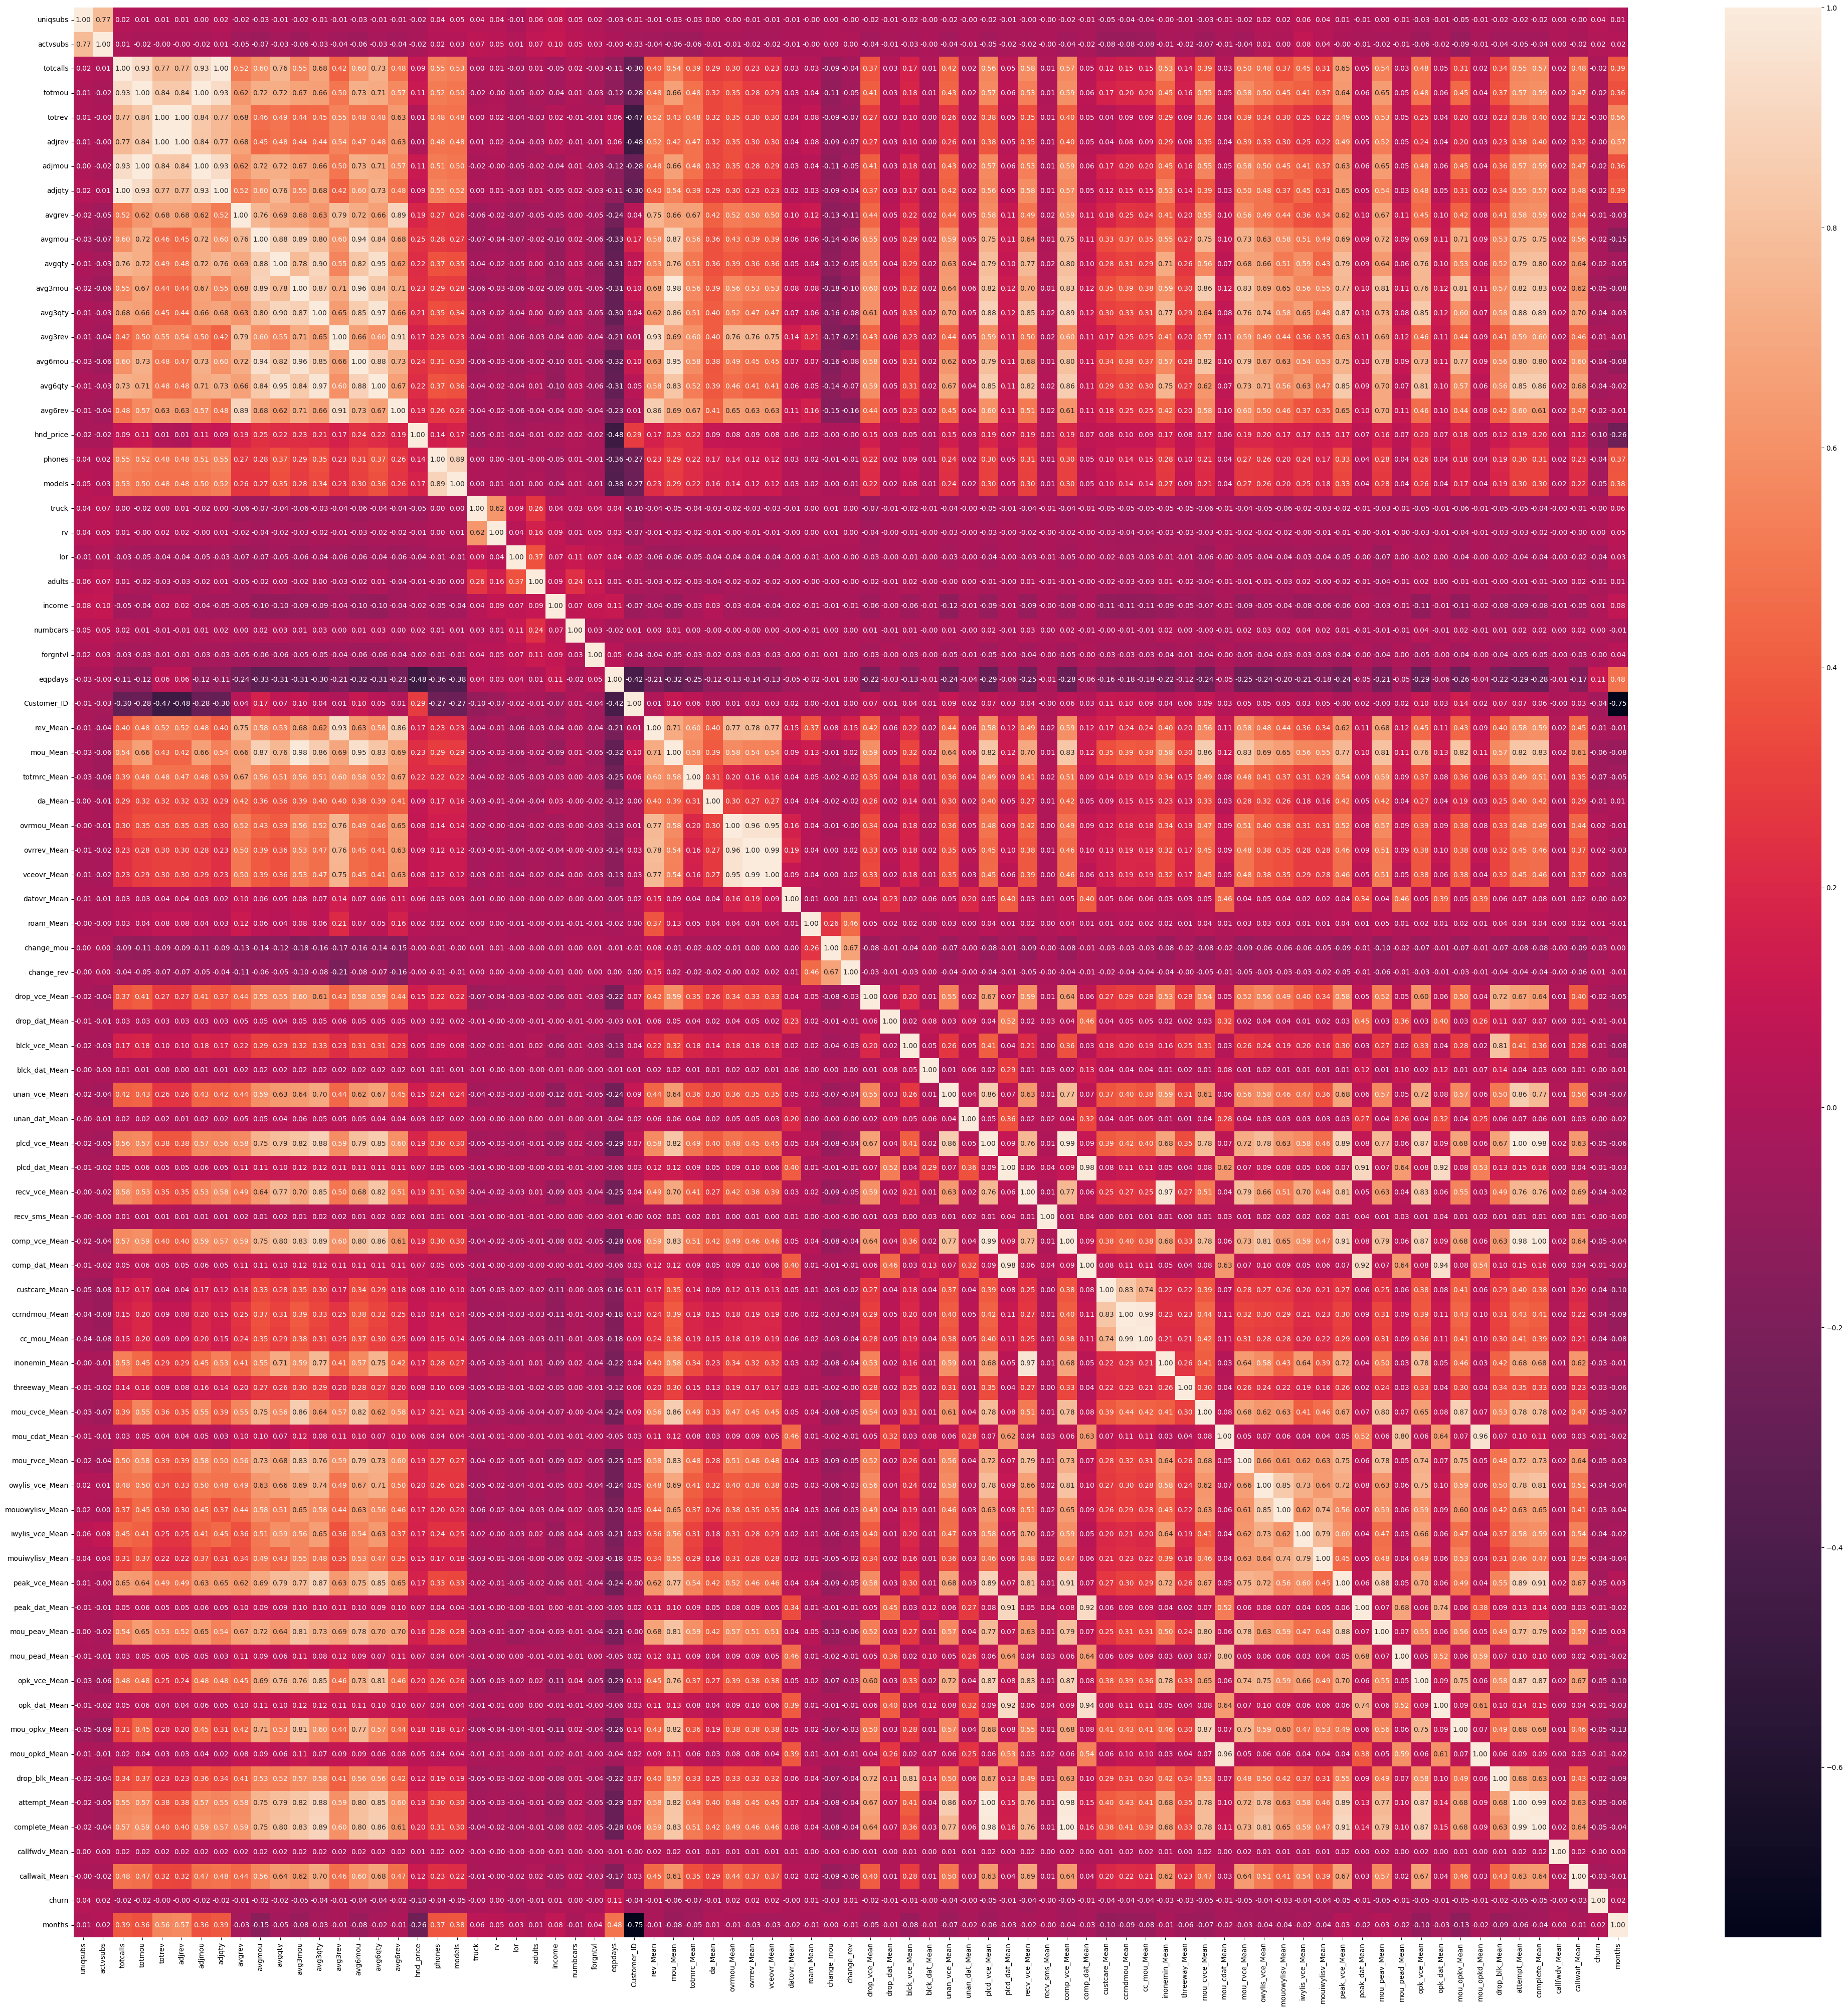

In [11]:
plt.figure(figsize=(50,50))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)
plt.show()

In [12]:
ones_matrix=np.ones(shape=corr_matrix.shape).astype(bool)
ones_matrix

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(79, 79))

In [13]:
corr_matrix=corr_matrix.abs()
mask=np.tril(ones_matrix,k=-1)
corr_matrix=corr_matrix.where(mask)
corr_matrix=corr_matrix.unstack()
corr_matrix=corr_matrix.dropna()

In [14]:
corr_matrix

uniqsubs       actvsubs    0.774229
               totcalls    0.022994
               totmou      0.007589
               totrev      0.011241
               adjrev      0.008911
                             ...   
callfwdv_Mean  churn       0.002248
               months      0.002313
callwait_Mean  churn       0.031082
               months      0.010747
churn          months      0.020991
Length: 3081, dtype: float64

In [15]:
high_corr=corr_matrix[corr_matrix>0.75]

In [16]:
high_corr

uniqsubs       actvsubs         0.774229
totcalls       totmou           0.925686
               totrev           0.771885
               adjrev           0.771358
               adjmou           0.925415
                                  ...   
mou_peav_Mean  complete_Mean    0.792675
opk_vce_Mean   mou_opkv_Mean    0.753291
               attempt_Mean     0.872396
               complete_Mean    0.872106
attempt_Mean   complete_Mean    0.985504
Length: 168, dtype: float64

In [17]:
high_corr=high_corr.reset_index()
high_corr.columns=["col_1","col_2","Value"]
high_corr

,col_1,col_2,Value
0,uniqsubs,actvsubs,0.774229
1,totcalls,totmou,0.925686
2,totcalls,totrev,0.771885
3,totcalls,adjrev,0.771358
4,totcalls,adjmou,0.925415
...,...,...,...
163,mou_peav_Mean,complete_Mean,0.792675
164,opk_vce_Mean,mou_opkv_Mean,0.753291
165,opk_vce_Mean,attempt_Mean,0.872396
166,opk_vce_Mean,complete_Mean,0.872106


In [18]:
unique_cols_corr=np.unique(np.array(high_corr["col_1"]))

In [19]:
unique_cols_corr

array(['Customer_ID', 'adjmou', 'adjqty', 'adjrev', 'attempt_Mean',
       'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev',
       'avgmou', 'avgqty', 'avgrev', 'blck_vce_Mean', 'ccrndmou_Mean',
       'comp_dat_Mean', 'comp_vce_Mean', 'custcare_Mean', 'inonemin_Mean',
       'iwylis_vce_Mean', 'mou_Mean', 'mou_cdat_Mean', 'mou_cvce_Mean',
       'mou_peav_Mean', 'mou_rvce_Mean', 'opk_vce_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'owylis_vce_Mean', 'peak_vce_Mean', 'phones',
       'plcd_dat_Mean', 'plcd_vce_Mean', 'recv_vce_Mean', 'rev_Mean',
       'totcalls', 'totmou', 'totrev', 'unan_vce_Mean', 'uniqsubs'],
      dtype=object)

In [20]:
len(list(unique_cols_corr))

41

In [21]:
important_columns = [
    'churn', 
    'drop_vce_Mean', 
    'blck_vce_Mean', 
    'custcare_Mean', 
    'drop_blk_Mean', 
    'change_mou', 
    'change_rev', 
    'rev_Mean', 
    'totmrc_Mean', 
    'ovrrev_Mean', 
    'avgrev', 
    'eqpdays', 
    'months', 
    'hnd_price', 
    'mou_Mean', 
    'totcalls', 
    'roam_Mean', 
    'income', 
    'area'
]
found=[]
for x in important_columns:
    if x in unique_cols_corr:
        found.append(x)
        
print(found)

['blck_vce_Mean', 'custcare_Mean', 'rev_Mean', 'ovrrev_Mean', 'avgrev', 'mou_Mean', 'totcalls']


In [22]:
unique_cols_corr=list(unique_cols_corr)
for c in found:
    unique_cols_corr.remove(c)

print(len(unique_cols_corr))

34


In [23]:
df_after_drop=full_data.drop(unique_cols_corr,axis=1)
df_after_drop.shape

(100000, 66)

In [24]:
numerical_cols=df_after_drop.select_dtypes(include=["number"])
corr_matrix=numerical_cols.corr()
ones_matrix=np.ones(shape=corr_matrix.shape).astype(bool)



In [25]:
corr_matrix=corr_matrix.abs()
mask=np.tril(ones_matrix,k=-1)
corr_matrix=corr_matrix.where(mask)
corr_matrix=corr_matrix.unstack()
corr_matrix=corr_matrix.dropna()
high_corr=corr_matrix[corr_matrix>0.75]
high_corr

avgrev         rev_Mean         0.750815
rev_Mean       ovrrev_Mean      0.776647
               vceovr_Mean      0.772159
mou_Mean       mou_opkv_Mean    0.816294
               complete_Mean    0.832570
ovrrev_Mean    vceovr_Mean      0.994752
blck_vce_Mean  drop_blk_Mean    0.811653
dtype: float64

In [26]:
"vceovr_Mean" in important_columns

False

In [27]:
df_after_drop.drop("vceovr_Mean",axis=1,inplace=True)

In [28]:
nan_sum=(df_after_drop.isna().sum())
nan_sum[nan_sum>0]

prizm_social_one     7388
area                   40
dualband                1
refurb_new              1
hnd_price             847
models                  1
hnd_webcap          10189
truck                1732
rv                   1732
ownrent             33706
lor                 30190
dwlltype            31909
marital              1732
adults              23019
infobase            22079
income              25436
numbcars            49366
HHstatin            37923
dwllsize            38308
forgntvl             1732
ethnic               1732
kid0_2               1732
kid3_5               1732
kid6_10              1732
kid11_15             1732
kid16_17             1732
creditcd             1732
eqpdays                 1
rev_Mean              357
mou_Mean              357
totmrc_Mean           357
da_Mean               357
ovrrev_Mean           357
datovr_Mean           357
roam_Mean             357
change_mou            891
change_rev            891
dtype: int64

In [29]:
cat_cols=df_after_drop.select_dtypes(include="object").columns
num_cols=df_after_drop.select_dtypes(include="number").columns
print(f"{len(list(cat_cols))}\n\n {len(list(num_cols))}")

21

 44


C:\Users\Access\AppData\Local\Temp\ipykernel_3220\1857159165.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_after_drop.select_dtypes(include="object").columns


In [30]:
print(cat_cols)
print(num_cols)

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
       'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2',
       'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='str')
Index(['actvsubs', 'totcalls', 'avgrev', 'hnd_price', 'models', 'truck', 'rv',
       'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays',
       'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrrev_Mean',
       'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean',
       'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_dat_Mean',
       'recv_sms_Mean', 'custcare_Mean', 'cc_mou_Mean', 'threeway_Mean',
       'mouowylisv_Mean', 'mouiwylisv_Mean', 'peak_dat_Mean', 'mou_pead_Mean',
       'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean',
       'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months'],
      dtype='str')


In [68]:
# pipline and column transformer for the data and select model to select the importance features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedShuffleSplit

In [69]:
splitter=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

for train_index,test_index in splitter.split(df_after_drop,df_after_drop["churn"]):
    strat_train=df_after_drop.loc[train_index]
    strat_test=df_after_drop.loc[test_index]

In [70]:
strat_train

,actvsubs,new_cell,crclscod,asl_flag,totcalls,avgrev,prizm_social_one,area,dualband,refurb_new,...,mou_pead_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
39301,1,U,BA,N,7810,118.81,U,CHICAGO AREA,Y,N,...,0.0,0.000000,97.650000,0.00,34.000000,180.333333,0.0,6.333333,1,20
51212,1,N,E4,Y,4333,59.87,S,ATLANTIC SOUTH AREA,Y,N,...,0.0,0.000000,761.720000,0.00,15.666667,179.666667,0.0,7.333333,0,19
6408,1,U,A,N,1928,39.30,S,NORTHWEST/ROCKY MOUNTAIN AREA,N,N,...,0.0,0.000000,24.690000,0.00,1.000000,64.000000,0.0,0.000000,0,33
57171,1,U,BA,N,85,29.10,U,SOUTHWEST AREA,Y,N,...,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0,11
89299,1,U,EA,Y,2074,96.98,NaN,CALIFORNIA NORTH AREA,N,N,...,0.0,0.000000,895.386667,0.00,21.000000,349.000000,0.0,15.000000,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86167,1,U,AA,N,3076,139.34,T,CHICAGO AREA,Y,N,...,0.0,0.000000,544.913333,0.00,21.333333,363.333333,0.0,8.666667,0,8
35165,1,U,AA,N,6178,111.78,S,LOS ANGELES AREA,N,N,...,0.0,0.333333,649.106667,0.69,22.000000,126.666667,0.0,0.000000,1,22
28246,1,N,ZA,N,4580,68.16,S,PHILADELPHIA AREA,Y,N,...,0.0,0.000000,178.870000,0.00,15.666667,225.333333,0.0,5.666667,0,23
32753,1,U,AA,N,162,23.57,S,OHIO AREA,Y,N,...,0.0,0.000000,0.873333,0.00,0.000000,4.666667,0.0,0.000000,0,23


In [100]:
strat_train_x=strat_train.drop("churn",axis=1)
strat_train_y=strat_train["churn"]

strat_test_x=strat_test.drop("churn",axis=1)
strat_test_y=strat_test["churn"]
num_cols=strat_train_x.select_dtypes(include="number").columns
cat_cols=strat_train_x.select_dtypes(include="object").columns

C:\Users\Access\AppData\Local\Temp\ipykernel_3220\2078512269.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=strat_train_x.select_dtypes(include="object").columns


In [101]:
num_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("std_scaler",StandardScaler()), 
])

cat_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoding",OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [102]:
col_transformer=ColumnTransformer(transformers=[
    ("number_preprocessing",num_pipe,num_cols),
    ("categorical_preprocessing",cat_pipe,cat_cols)
])

In [103]:
pre_data_x=col_transformer.fit_transform(strat_train_x)
type(pre_data_x)

df_pre_data_x=pd.DataFrame(
    pre_data_x,
    columns=col_transformer.get_feature_names_out()
)

In [104]:
pre_data_test_x=col_transformer.transform(strat_test_x)

df_pre_data_test_x=pd.DataFrame(
    pre_data_test_x,
    columns=col_transformer.get_feature_names_out()
)

In [105]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(df_pre_data_x,strat_train_y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [106]:
from sklearn.metrics import classification_report

y_pred=model.predict(df_pre_data_test_x)

classification_report(strat_test_y,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.64      0.63      0.64     10088\n           1       0.63      0.64      0.64      9912\n\n    accuracy                           0.64     20000\n   macro avg       0.64      0.64      0.64     20000\nweighted avg       0.64      0.64      0.64     20000\n'

In [131]:
importance_dict = model.get_booster().get_score(importance_type='gain')

df_importance = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

total_gain = df_importance['Gain'].sum()
df_importance['Importance_Percentage'] = (df_importance['Gain'] / total_gain) * 100

df_top = df_importance.sort_values(by='Importance_Percentage', ascending=False).head(15)

top_col=list(df_top["Feature"])

df_top

,Feature,Gain,Importance_Percentage
12,number_preprocessing__eqpdays,33.242535,5.521488
49,categorical_preprocessing__refurb_new,28.721167,4.770502
42,number_preprocessing__months,26.811747,4.453353
3,number_preprocessing__hnd_price,18.377941,3.052522
45,categorical_preprocessing__asl_flag,16.005058,2.658393
14,number_preprocessing__mou_Mean,14.562043,2.418713
15,number_preprocessing__totmrc_Mean,14.024442,2.329419
63,categorical_preprocessing__creditcd,14.000301,2.325409
20,number_preprocessing__change_mou,13.804808,2.292938
44,categorical_preprocessing__crclscod,11.834455,1.965668


In [132]:
top_col

['number_preprocessing__eqpdays',
 'categorical_preprocessing__refurb_new',
 'number_preprocessing__months',
 'number_preprocessing__hnd_price',
 'categorical_preprocessing__asl_flag',
 'number_preprocessing__mou_Mean',
 'number_preprocessing__totmrc_Mean',
 'categorical_preprocessing__creditcd',
 'number_preprocessing__change_mou',
 'categorical_preprocessing__crclscod',
 'number_preprocessing__totcalls',
 'number_preprocessing__ovrrev_Mean',
 'number_preprocessing__lor',
 'categorical_preprocessing__marital',
 'number_preprocessing__avgrev']

In [133]:
kl=[]
for x in top_col:
    for c in important_columns:
        if c in x :
            kl.append(x)
            
kl
            

['number_preprocessing__eqpdays',
 'number_preprocessing__months',
 'number_preprocessing__hnd_price',
 'number_preprocessing__mou_Mean',
 'number_preprocessing__totmrc_Mean',
 'number_preprocessing__change_mou',
 'number_preprocessing__totcalls',
 'number_preprocessing__ovrrev_Mean',
 'number_preprocessing__ovrrev_Mean',
 'number_preprocessing__avgrev']

In [134]:
print(len(kl))
print(len(important_columns))

10
19
